### Load Dataset

In [1]:
import pandas as pd
df = pd.read_csv("big_market_sales_dataset.csv")
df.head()


,Item_ID,Item_Category,Item_MRP,Item_Visibility,Item_Fat_Content,Outlet_ID,Outlet_Type,Outlet_Size,Outlet_Location_Type,Outlet_Establishment_Year,Festival_Flag,Discount_Percentage,Units_Sold
0,ITM_00001,Personal Care,216.20,0.16,Low Fat,OUT_000,Supermarket Type3,Medium,Tier 3,2010,0,6,60
1,ITM_00002,Clothing,225.88,0.19,Non Edible,OUT_001,Supermarket Type3,Small,Tier 2,1997,0,42,115
2,ITM_00003,Household,301.07,0.19,Non Edible,OUT_002,Supermarket Type1,Medium,Tier 1,1996,0,36,160
3,ITM_00004,Clothing,270.16,0.06,Regular,OUT_003,Grocery Store,Medium,Tier 2,2006,0,8,33
4,ITM_00005,Clothing,91.89,0.21,Non Edible,OUT_004,Supermarket Type2,Medium,Tier 1,1993,1,13,149


In [2]:
# Clean Item_Fat_Content column

# 1. Create Is_Food column
df['Is_Food'] = df['Item_Fat_Content'].apply(lambda x: 1 if x in ['Low Fat', 'Regular'] else 0)

# 2. Standardize Item_Fat_Content
def standardize_fat_content(value):
    if value in ['Low Fat', 'low fat', 'LF']:
        return 'Low Fat'
    elif value in ['Regular', 'reg']:
        return 'Regular'
    elif value == 'Non Edible':
        return 'Non-Food'
    else:
        return value  # in case of other values

df['Item_Fat_Content'] = df['Item_Fat_Content'].apply(standardize_fat_content)

# 3. Ensure no inconsistent values - check unique values
print("Unique values in Item_Fat_Content after cleaning:")
print(df['Item_Fat_Content'].unique())

# 4. Show value counts
print("\nValue counts for Item_Fat_Content:")
print(df['Item_Fat_Content'].value_counts())

print("\nValue counts for Is_Food:")
print(df['Is_Food'].value_counts())

Unique values in Item_Fat_Content after cleaning:
['Low Fat' 'Non-Food' 'Regular']

Value counts for Item_Fat_Content:
Item_Fat_Content
Regular     3435
Low Fat     3284
Non-Food    3281
Name: count, dtype: int64

Value counts for Is_Food:
Is_Food
1    6719
0    3281
Name: count, dtype: int64


### Dataset Overview

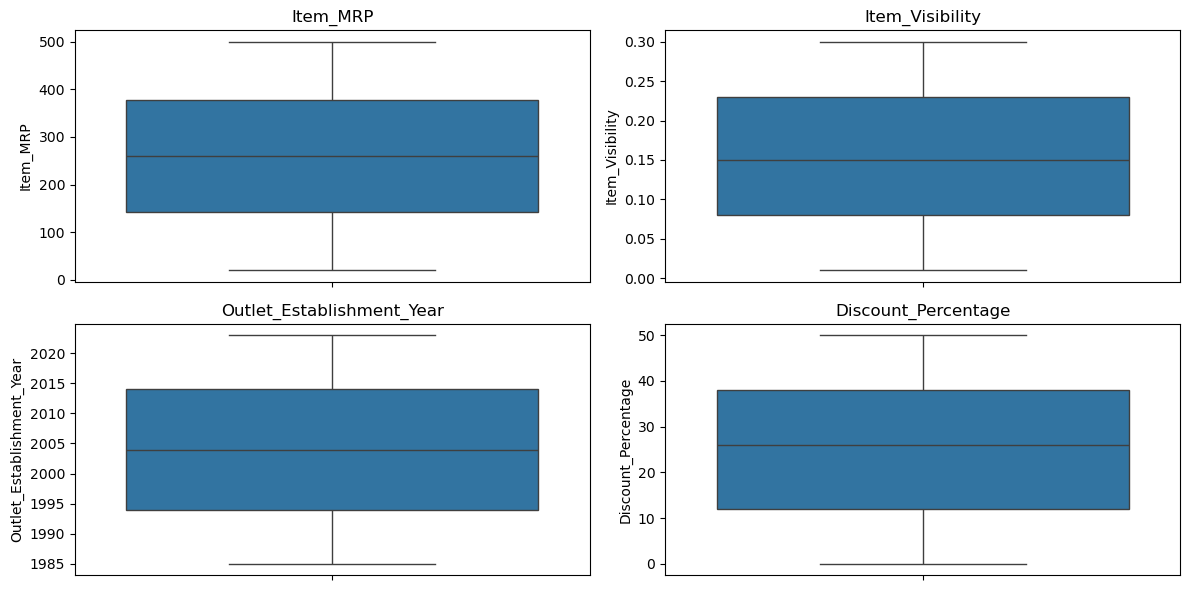

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'Item_MRP',
    'Item_Visibility',
    'Outlet_Establishment_Year',
    'Discount_Percentage'
]

plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_ID                    10000 non-null  object 
 1   Item_Category              10000 non-null  object 
 2   Item_MRP                   10000 non-null  float64
 3   Item_Visibility            10000 non-null  float64
 4   Item_Fat_Content           10000 non-null  object 
 5   Outlet_ID                  10000 non-null  object 
 6   Outlet_Type                10000 non-null  object 
 7   Outlet_Size                10000 non-null  object 
 8   Outlet_Location_Type       10000 non-null  object 
 9   Outlet_Establishment_Year  10000 non-null  int64  
 10  Festival_Flag              10000 non-null  int64  
 11  Discount_Percentage        10000 non-null  int64  
 12  Units_Sold                 10000 non-null  int64  
 13  Is_Food                    10000 non-null  int6

In [5]:
df.isnull().sum()

Item_ID                      0
Item_Category                0
Item_MRP                     0
Item_Visibility              0
Item_Fat_Content             0
Outlet_ID                    0
Outlet_Type                  0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Establishment_Year    0
Festival_Flag                0
Discount_Percentage          0
Units_Sold                   0
Is_Food                      0
dtype: int64

### Drop ID Columns

In [6]:
df.drop(["Item_ID", "Outlet_ID"], axis=1, inplace=True)

In [7]:
df.head()

,Item_Category,Item_MRP,Item_Visibility,Item_Fat_Content,Outlet_Type,Outlet_Size,Outlet_Location_Type,Outlet_Establishment_Year,Festival_Flag,Discount_Percentage,Units_Sold,Is_Food
0,Personal Care,216.20,0.16,Low Fat,Supermarket Type3,Medium,Tier 3,2010,0,6,60,1
1,Clothing,225.88,0.19,Non-Food,Supermarket Type3,Small,Tier 2,1997,0,42,115,0
2,Household,301.07,0.19,Non-Food,Supermarket Type1,Medium,Tier 1,1996,0,36,160,0
3,Clothing,270.16,0.06,Regular,Grocery Store,Medium,Tier 2,2006,0,8,33,1
4,Clothing,91.89,0.21,Non-Food,Supermarket Type2,Medium,Tier 1,1993,1,13,149,0


### Separate Features & Target

In [8]:
X = df.drop("Units_Sold", axis=1)
y = df["Units_Sold"]

In [9]:
X.head()

,Item_Category,Item_MRP,Item_Visibility,Item_Fat_Content,Outlet_Type,Outlet_Size,Outlet_Location_Type,Outlet_Establishment_Year,Festival_Flag,Discount_Percentage,Is_Food
0,Personal Care,216.20,0.16,Low Fat,Supermarket Type3,Medium,Tier 3,2010,0,6,1
1,Clothing,225.88,0.19,Non-Food,Supermarket Type3,Small,Tier 2,1997,0,42,0
2,Household,301.07,0.19,Non-Food,Supermarket Type1,Medium,Tier 1,1996,0,36,0
3,Clothing,270.16,0.06,Regular,Grocery Store,Medium,Tier 2,2006,0,8,1
4,Clothing,91.89,0.21,Non-Food,Supermarket Type2,Medium,Tier 1,1993,1,13,0


In [10]:
y.head()

0     60
1    115
2    160
3     33
4    149
Name: Units_Sold, dtype: int64

### Identify Column Types

In [11]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [12]:
cat_cols

Index(['Item_Category', 'Item_Fat_Content', 'Outlet_Type', 'Outlet_Size',
       'Outlet_Location_Type'],
      dtype='object')

In [13]:
num_cols

Index(['Item_MRP', 'Item_Visibility', 'Outlet_Establishment_Year',
       'Festival_Flag', 'Discount_Percentage', 'Is_Food'],
      dtype='object')

### Preprocessing

In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(drop="first"), cat_cols),
        ("numerical", StandardScaler(), num_cols)
    ]
)

preprocessor


ColumnTransformer(transformers=[('categorical', OneHotEncoder(drop='first'),
                                 Index(['Item_Category', 'Item_Fat_Content', 'Outlet_Type', 'Outlet_Size',
       'Outlet_Location_Type'],
      dtype='object')),
                                ('numerical', StandardScaler(),
                                 Index(['Item_MRP', 'Item_Visibility', 'Outlet_Establishment_Year',
       'Festival_Flag', 'Discount_Percentage', 'Is_Food'],
      dtype='object'))])

In [15]:
### Remove Outliers using IQR Method
from scipy import stats

# Calculate IQR for Units_Sold (target variable)
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
mask = (y >= lower_bound) & (y <= upper_bound)
X_clean = X[mask]
y_clean = y[mask]

print(f"Original dataset size: {len(X)}")
print(f"Cleaned dataset size: {len(X_clean)}")
print(f"Outliers removed: {len(X) - len(X_clean)}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")


Original dataset size: 10000
Cleaned dataset size: 9983
Outliers removed: 17
Lower bound: -2.5, Upper bound: 225.5


### Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (7986, 11)
Testing data shape : (1997, 11)


### Random Forest Model

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Item_Category', 'Item_Fat_Content', 'Outlet_Type', 'Outlet_Size',
       'Outlet_Location_Type'],
      dtype='object')),
                                                 ('numerical', StandardScaler(),
                                                  Index(['Item_MRP', 'Item_Visibility', 'Outlet_Establishment_Year',
       'Festival_Flag', 'Discount_Percentage', 'Is_Food'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [18]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Item_Category', 'Item_Fat_Content', 'Outlet_Type', 'Outlet_Size',
       'Outlet_Location_Type'],
      dtype='object')),
                                                 ('numerical', StandardScaler(),
                                                  Index(['Item_MRP', 'Item_Visibility', 'Outlet_Establishment_Year',
       'Festival_Flag', 'Discount_Percentage', 'Is_Food'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=150, n_jobs=-1,
                                       random_state=42))])

In [19]:
y_pred = rf_model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("=" * 50)
print("RANDOM FOREST REGRESSOR - PERFORMANCE METRICS")
print("=" * 50)
print(f"Mean Absolute Error (MAE)  : {mae:.4f}")
print(f"Mean Squared Error (MSE)   : {mse:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")
print(f"Mean Absolute % Error      : {mape:.4f}")
print("=" * 50)

RANDOM FOREST REGRESSOR - PERFORMANCE METRICS
Mean Absolute Error (MAE)  : 12.6855
Mean Squared Error (MSE)   : 249.7921
Root Mean Squared Error    : 15.8048
R² Score                   : 0.8344
Mean Absolute % Error      : 0.1344


In [21]:
rf = rf_model.named_steps["model"]
feature_names = rf_model.named_steps["preprocessing"].get_feature_names_out()

import pandas as pd
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)


,Feature,Importance
18,numerical__Discount_Percentage,0.577361
17,numerical__Festival_Flag,0.158919
13,categorical__Outlet_Location_Type_Tier 3,0.065080
12,categorical__Outlet_Location_Type_Tier 2,0.064697
14,numerical__Item_MRP,0.034124
15,numerical__Item_Visibility,0.032509
16,numerical__Outlet_Establishment_Year,0.027087
10,categorical__Outlet_Size_Medium,0.003828
6,categorical__Item_Fat_Content_Regular,0.003582
11,categorical__Outlet_Size_Small,0.003447


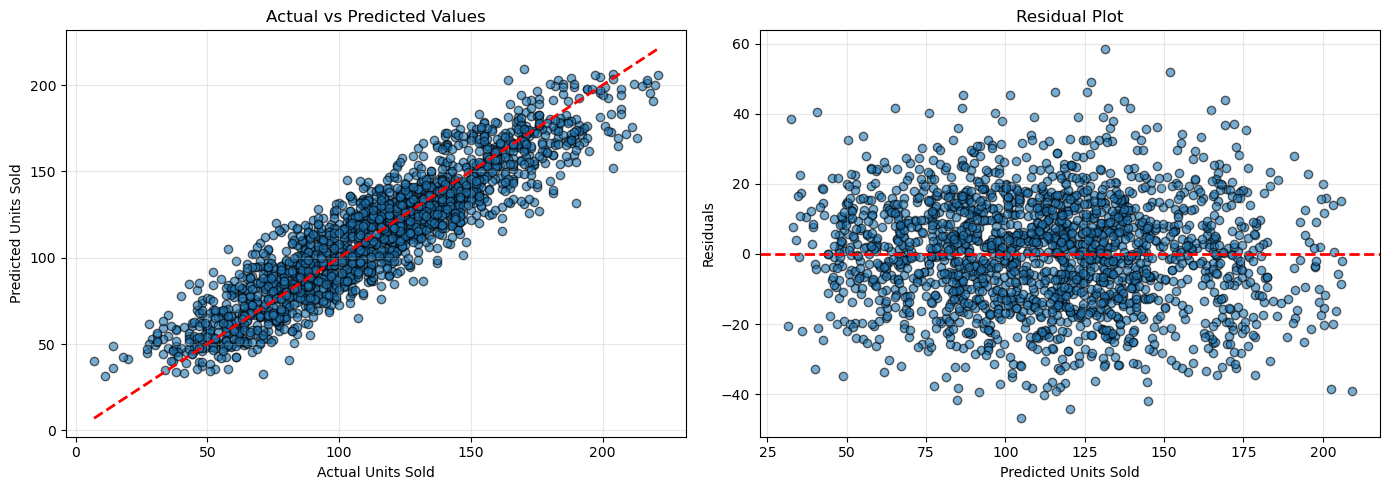

Residuals Mean: 0.3984
Residuals Std Dev: 15.8037


In [22]:
### Actual vs Predicted & Residuals Analysis
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Units Sold')
axes[0].set_ylabel('Predicted Units Sold')
axes[0].set_title('Actual vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Units Sold')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals Mean: {residuals.mean():.4f}")
print(f"Residuals Std Dev: {residuals.std():.4f}")

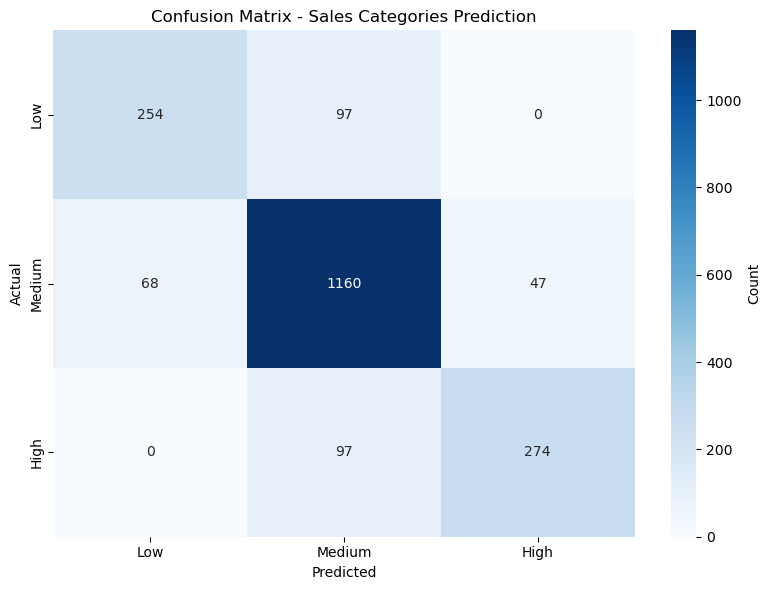


Classification Report - Sales Categories:
              precision    recall  f1-score   support

         Low       0.79      0.72      0.75       351
      Medium       0.86      0.91      0.88      1275
        High       0.85      0.74      0.79       371

    accuracy                           0.85      1997
   macro avg       0.83      0.79      0.81      1997
weighted avg       0.84      0.85      0.84      1997



In [23]:
### Prediction Categories & Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

# Create categories: Low (< 75), Medium (75-150), High (> 150)
def categorize(val):
    if val < 75:
        return 'Low'
    elif val < 150:
        return 'Medium'
    else:
        return 'High'

y_test_cat = y_test.apply(categorize)
y_pred_cat = pd.Series(y_pred).apply(categorize)

# Confusion Matrix
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=['Low', 'Medium', 'High'])

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Sales Categories Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nClassification Report - Sales Categories:")
print(classification_report(y_test_cat, y_pred_cat, labels=['Low', 'Medium', 'High']))

In [24]:
sample = pd.DataFrame({
    "Item_Category": ["Food"],
    "Item_MRP": [180],
    "Item_Visibility": [0.12],
    "Item_Fat_Content": ["Low Fat"],
    "Outlet_Type": ["Supermarket Type1"],
    "Outlet_Size": ["Medium"],
    "Outlet_Location_Type": ["Tier 1"],
    "Outlet_Establishment_Year": [2010],
    "Festival_Flag": [1],
    "Discount_Percentage": [25]
})

# Add the derived feature required by the pipeline
sample["Is_Food"] = sample["Item_Fat_Content"].apply(lambda x: 1 if x in ["Low Fat", "Regular"] else 0)

print(rf_model.predict(sample))


[171.26]


In [25]:
## Model Performance Summary
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Accuracy (R² Score)        : {r2:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"Mean Absolute Error        : {mae:.4f}")
print("="*60)


MODEL PERFORMANCE SUMMARY
Accuracy (R² Score)        : 0.8344
Root Mean Squared Error    : 15.8048
Mean Absolute Error        : 12.6855
